In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

### Load and Explore the Data:

In [23]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/muhammetvarl/laptop-price
# Or use the direct path to your CSV file

laptop_data = pd.read_csv('laptop_price.csv', encoding='latin1')
laptop_data.sample(5, replace = False)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
39,40,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Nvidia GeForce 930MX,Windows 10,2.1kg,879.0
46,47,Lenovo,IdeaPad 320-15ISK,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4GB,128GB SSD,Intel HD Graphics 520,No OS,2.2kg,369.0
449,456,Microsoft,Surface Laptop,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10 S,1.25kg,2589.0
369,375,HP,Elitebook 1040,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.36kg,1750.0
1157,1175,Lenovo,ThinkPad T460s,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 6600U 2.6GHz,12GB,512GB SSD,Intel HD Graphics 520,Windows 7,1.4kg,2299.0


In [24]:
# Display basic information
print(f"\n Dataset Shape: {laptop_data.shape[0]} rows × {laptop_data.shape[1]} columns")


 Dataset Shape: 1303 rows × 13 columns


In [25]:
# Check for missing values
print(laptop_data.isnull().sum().sort_values(ascending = False))


laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [27]:
# checking datatypes
laptop_data.dtypes

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

In [28]:
# statistical summery
laptop_data.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


### Data Preprocessing:

In [31]:
# Copy the dataset for ensuring not changing in data.
laptop_df = laptop_data.copy()
laptop_df.head(2)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94


In [47]:
# Handle missing values if any
df_processed = laptop_df.dropna()
print(f"Rows after removing missing values: {df_processed.shape[0]}")

Rows after removing missing values: 1303


In [46]:
# Encode categorical variables
# Identify categorical columns
categorical_cols = laptop_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns found: {categorical_cols}")

Categorical columns found: ['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']


In [38]:
# Initialize label encoders
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in categorical_cols:
    if col != 'laptop_ID':  # Skip ID column if exists
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f" Encoded: {col}")

 Encoded: Company
 Encoded: Product
 Encoded: TypeName
 Encoded: ScreenResolution
 Encoded: Cpu
 Encoded: Ram
 Encoded: Memory
 Encoded: Gpu
 Encoded: OpSys
 Encoded: Weight


### Feature Selection and Label Encoder:

In [45]:
# Assuming 'Price' or 'Price_euros' is the target column
# Adjust this based on your actual dataset column name
price_columns = [col for col in df_processed.columns if 'price' in col.lower()]
if price_columns:
    target_col = price_columns[0]
else:
    # If no price column found, use the last column as target
    target_col = df_processed.columns[-1]

print(f"Target Variable: {target_col}")


Target Variable: Price_euros


In [44]:
# Remove non-numeric columns and target from features
X = df_processed.drop(columns=[target_col])

# Remove ID columns if they exist
X = X.select_dtypes(include=[np.number])

y = df_processed[target_col]

print(f"Features selected: {X.shape[1]} features")
print(f"Feature names: {list(X.columns)}")

Features selected: 12 features
Feature names: ['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']


### Spliting Data Training and Test sets:


In [41]:
# Split with 80-20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Training set: 1042 samples
Testing set: 261 samples


### Training Linear Regression Model:

In [43]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [48]:
 # Display model coefficients
print(f"Model Intercept: {model.intercept_:.2f}")
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"   {feature}: {coef:.4f}")


Model Intercept: -1749.54

Feature Coefficients:
   laptop_ID: 0.1548
   Company: 3.3651
   Product: -0.0110
   TypeName: -4.2915
   Inches: 79.4423
   ScreenResolution: 20.1832
   Cpu: 8.9833
   Ram: -43.5174
   Memory: 10.9793
   Gpu: 7.1408
   OpSys: 130.1653
   Weight: -2.7352


### Making Prediction:

In [50]:
# Predictions on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions completed!")


Predictions completed!


### Model Evaluation:

In [53]:
# Calculate metrics for training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Mean Squared Error (MSE): {train_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {train_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {train_mae:.2f}")
print(f"R² Score: {train_r2:.4f}")


Mean Squared Error (MSE): 241353.06
Root Mean Squared Error (RMSE): 491.28
Mean Absolute Error (MAE): 365.39
R² Score: 0.5005


In [54]:
# Calculate metrics for test set
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE): {test_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {test_mae:.2f}")
print(f"R² Score: {test_r2:.4f}")

Mean Squared Error (MSE): 303594.18
Root Mean Squared Error (RMSE): 550.99
Mean Absolute Error (MAE): 371.90
R² Score: 0.4023


### Model Accuracy Interpretition:

In [56]:
print(f"The model explains {test_r2*100:.2f}% of the variance in laptop prices")
print(f"Average prediction error: +&-{test_mae:.2f} units")

The model explains 40.23% of the variance in laptop prices
Average prediction error: +&-371.90 units


### Visualization:

In [57]:
# Set styling for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


Visualizations saved as 'laptop_price_analysis.png'


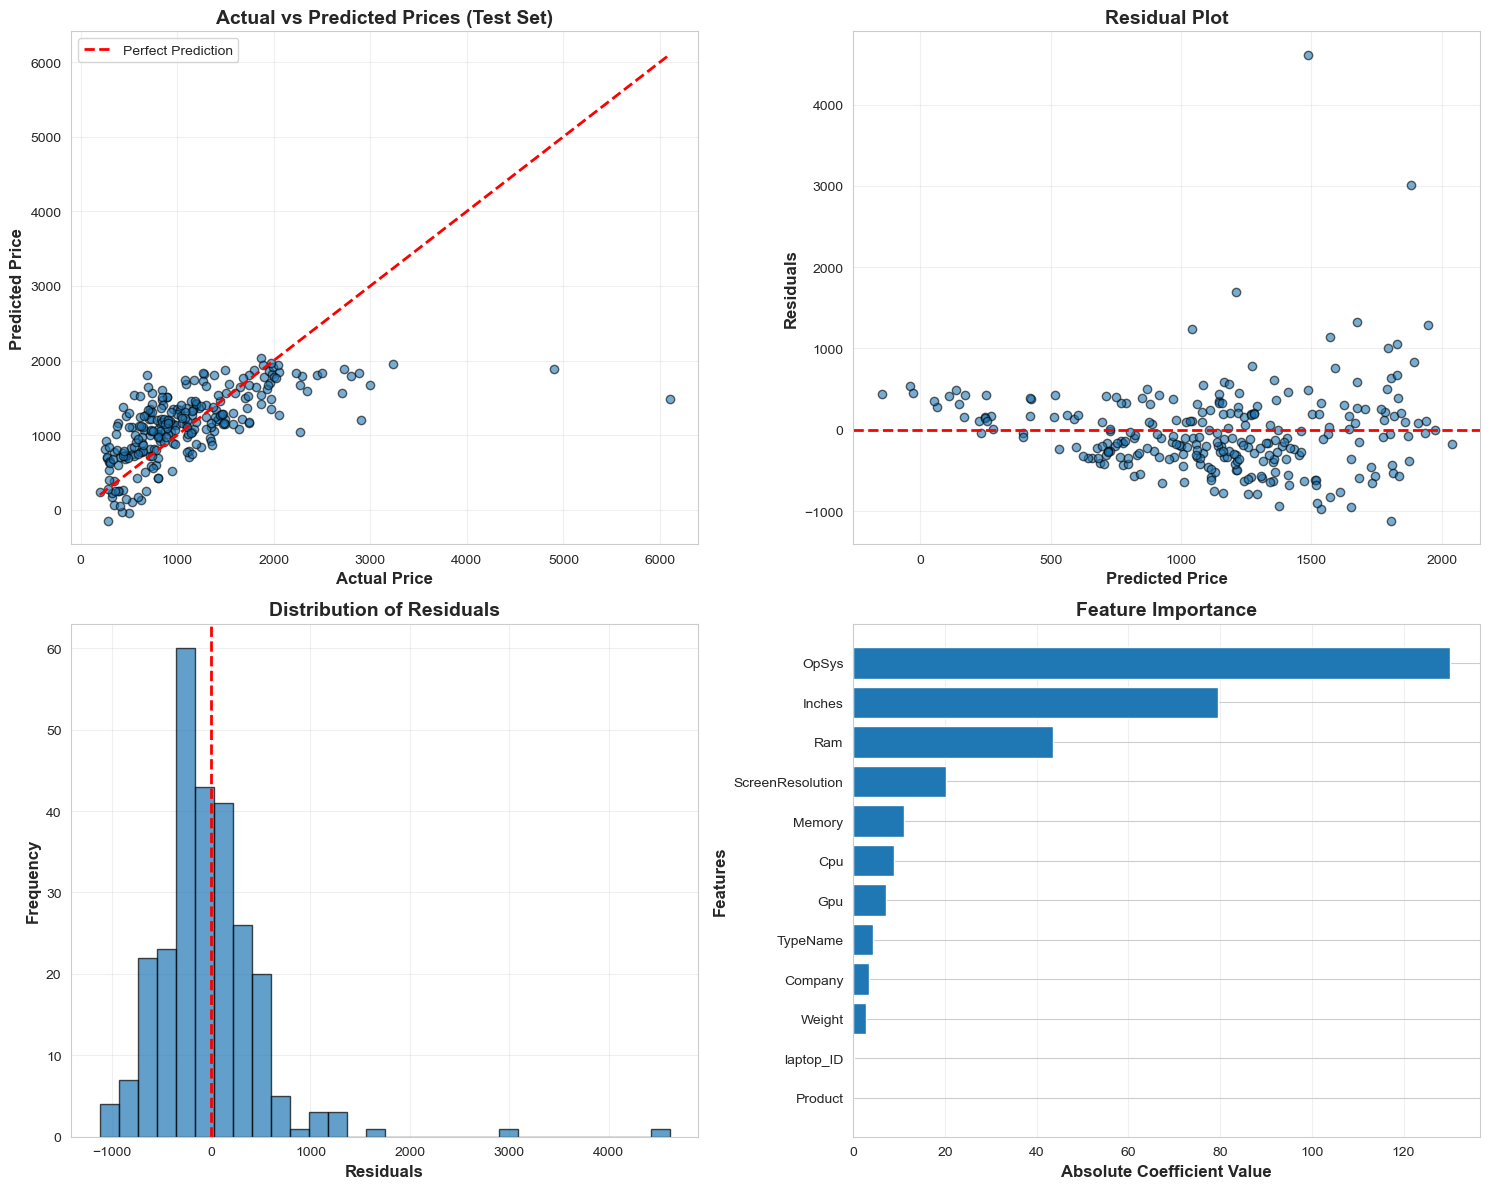

In [60]:
 # Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted Prices (Test Set)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Predicted Price', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Actual vs Predicted Prices (Test Set)', 
                     fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual Plot
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.6, edgecolors='k')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Residuals
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature Importance (Absolute Coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(model.coef_)
}).sort_values('Coefficient', ascending=True)

axes[1, 1].barh(feature_importance['Feature'], 
                feature_importance['Coefficient'])
axes[1, 1].set_xlabel('Absolute Coefficient Value', 
                      fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Features', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('laptop_price_analysis.png', dpi=300, bbox_inches='tight')
print("Visualizations saved as 'laptop_price_analysis.png'")


### Sample Prediction:

In [61]:
# Show first 10 predictions
comparison_df = pd.DataFrame({
    'Actual Price': y_test[:10].values,
    'Predicted Price': y_test_pred[:10],
    'Difference': y_test[:10].values - y_test_pred[:10]
})
comparison_df['Accuracy %'] = (1 - abs(comparison_df['Difference']) / 
                                comparison_df['Actual Price']) * 100

print("\n", comparison_df.to_string(index=False))


  Actual Price  Predicted Price  Difference  Accuracy %
      1672.00      1222.028936  449.971064   73.087855
      1149.00      1265.042960 -116.042960   89.900526
       499.00       -37.945361  536.945361   -7.604281
       899.00      1514.658775 -615.658775   31.517378
      1244.00       848.694834  395.305166   68.223057
      1398.99      1189.592452  209.397548   85.032234
       719.00       818.017306  -99.017306   86.228469
       459.00       677.371419 -218.371419   52.424527
      1191.00      1388.529790 -197.529790   83.414795
       349.00       392.510505  -43.510505   87.532807
